In [ ]:
!pip install dcor

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import typing as tp
from numpy import array
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error,  root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import random
import os
import tensorflow as tf


In [ ]:
import tesis_funciones_v5 as tf

In [ ]:
import univariate_lstm_importable as um

In [ ]:
import random

def get_random_hex(seed=42):
    """
    Genera un color hexadecimal aleatorio.
    """
    random.seed(seed)
    r = random.randint(0, 255)
    g = random.randint(0, 255)
    b = random.randint(0, 255)
    return f'#{r:02X}{g:02X}{b:02X}'

In [ ]:
def get_the_scatter_index(series12: list[str], vec: np.array = np.zeros(100)) -> int:
  """
  Devuelve el índice de la mse de la predicción cruzada sobre la serie2, con
  el modelo entrenado por la serie1.
  """
  index_s1 = name_num[series12[0]]
  index_s2 = name_num[series12[1]]
  trnd_serie1 = vec[10*index_s1:10*index_s1+10]
  cross_mse = trnd_serie1[index_s2]
  cross_mse_index = 10*index_s1 + index_s2
  return (cross_mse_index, cross_mse)

In [ ]:
test_time_series = um.test_time_series
models = um.models_64
test_x = um.test_x_sequences
test_y = um.test_y_sequences
normal_train_predictions = um.get_the_train_curves(um.models_64, um.train_time_series,
                                                   um.train_x_sequences, tf.colores_complementarios)
normal_test_predictions = um.get_the_train_curves(um.models_64, um.test_time_series,
                                                 um.test_x_sequences, tf.colores_complementarios)

In [ ]:
#No volver a ejecutar
for ts in test_time_series:
  ts.name = ts.name[:-len(" (test)")]
  print(ts.name)

NIKKEI
SP500
DAX40
FTSE250
MEX
BTC
ETHEREUM
XRP
DOGE
TETHER


In [ ]:
name_num: dict = {tf.nombres[i]: i for i in range(len(tf.nombres))}

In [ ]:
pcc = np.round(np.corrcoef(tf.N_returns), 2)
dcc = tf.DCC_matrix(tf.N_returns.to_numpy())

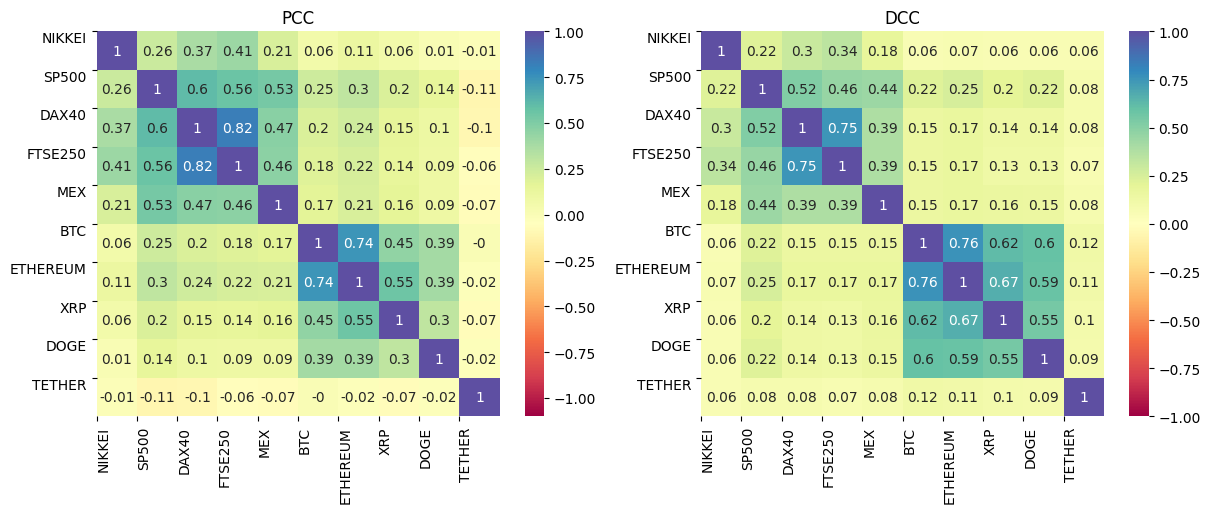

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14.3, 5))
sns.heatmap(pcc, cmap = 'Spectral', annot=True, vmin=1, vmax=-1, ax = axes[0])
axes[0].set_title("PCC")

sns.heatmap(dcc, cmap = 'Spectral', annot=True, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("DCC")

for ax in axes:
  ax.set_xticks(range(10), tf.Precios.index, rotation = 90, ha = "left")
  ax.set_yticks(range(10), tf.Precios.index, rotation = 0, va = "top")

## PCC
####-Máx = 0.82 (DAX40 y FTSE250)
####-Min = -0.11 (TETHER Y SP500)

## DCC
####-Máx = 0.76 (ETH y BTC)
####-Min = 0.06 (NIKKEI y Criptos excepto ETH)

In [ ]:
mses, rmses, pccs, dccs = np. zeros((100)), np.zeros((100)), np.zeros((100)), np.zeros((100))
cross_pred = []
index = 0
for i in range(10):
  for j in range(10):
    #if j != i:
      pred = models[i].predict(test_x[j], verbose = 0).flatten()
      mse, rmse = mean_squared_error(test_y[j], pred), root_mean_squared_error(test_y[j], pred)
      rmses[index] = rmse
      mses[index] = mse
      pccs[index] = pcc[i, j]
      dccs[index] = dcc[i, j]
      cross_pred.append(tf.TimeSeries(pd.Series(pred, index = tf.ref_time_series.data.index[um.len_train:-5]),
                                      name = f"{tf.nombres[j]}_trnd_{tf.nombres[i]}", color = get_random_hex(seed = index)))
      index += 1

In [ ]:
#La salida debería ser -0.11:
pccs[get_the_scatter_index(["TETHER", "SP500"], pccs)[0]]

np.float64(-0.11)

# Comparamos las predicciones cruzadas

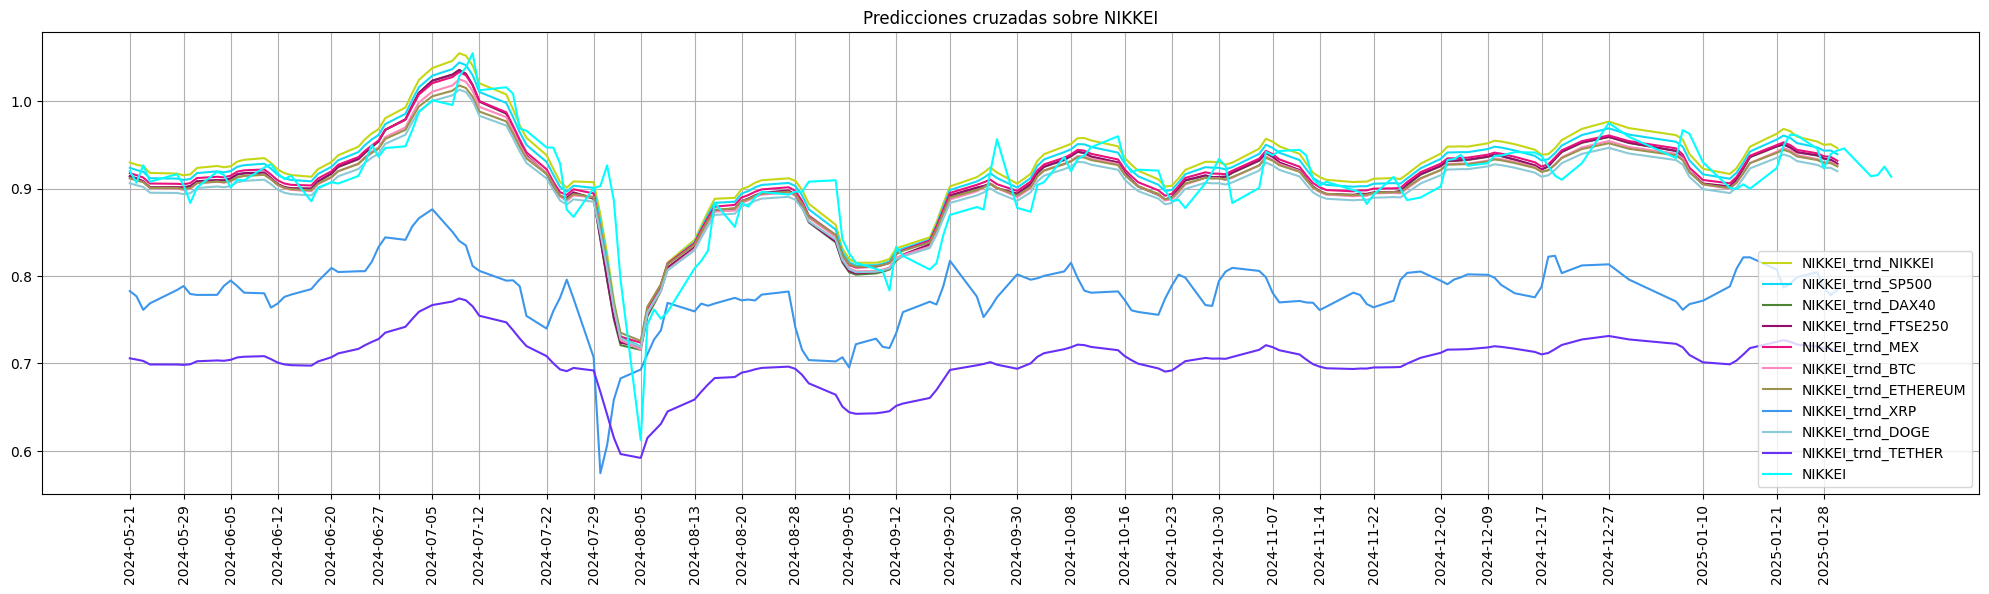

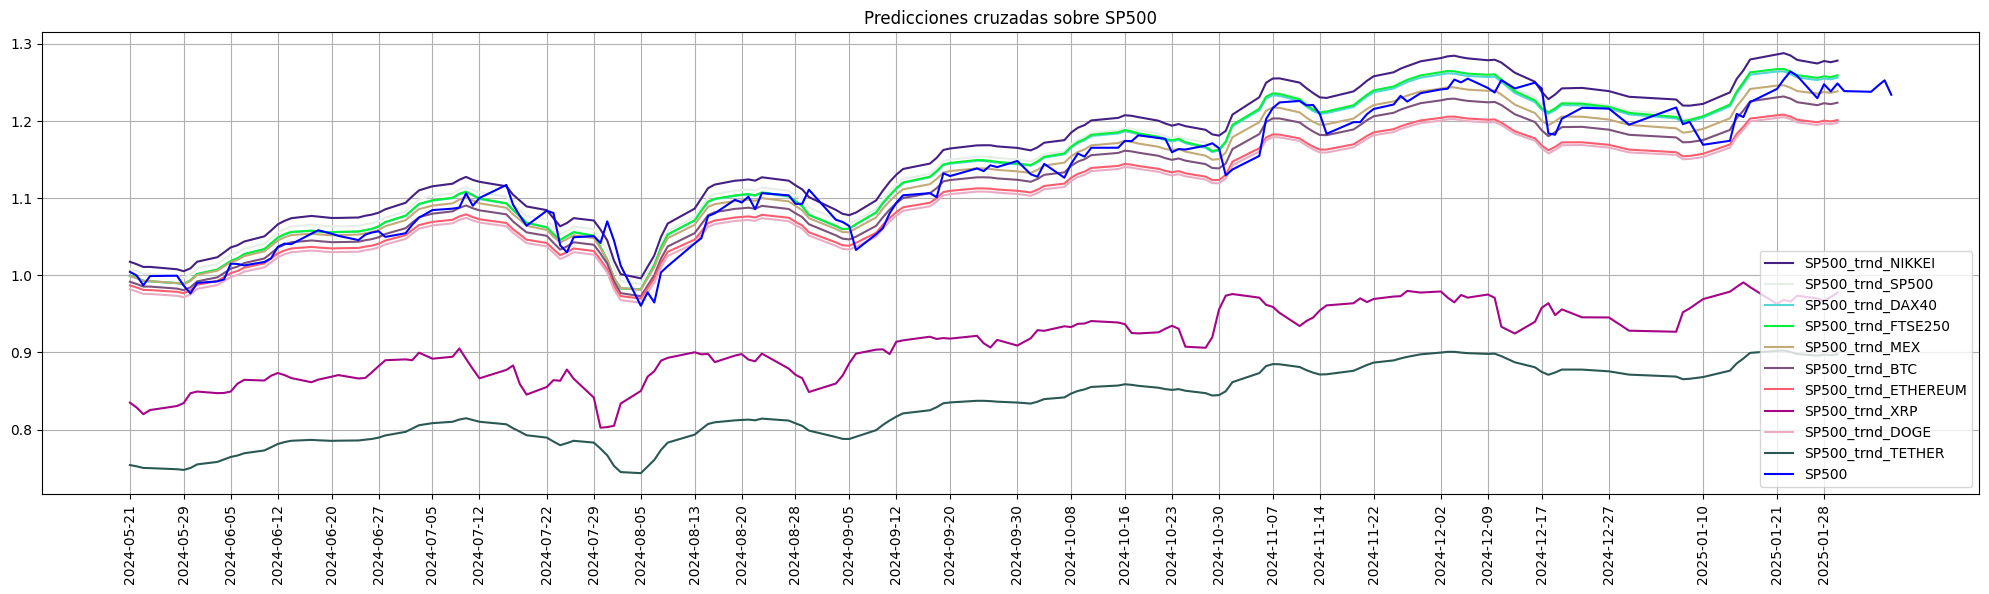

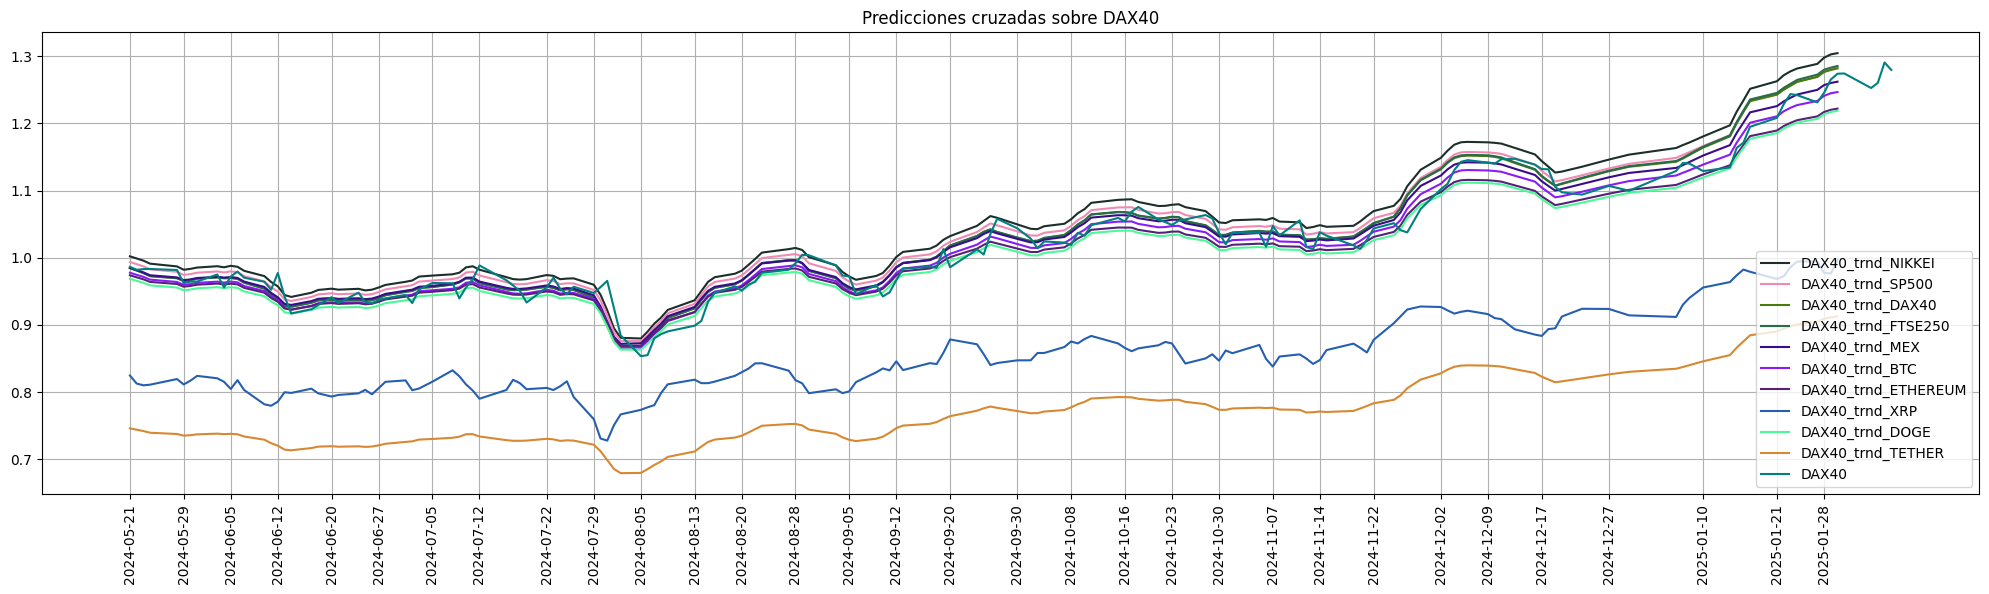

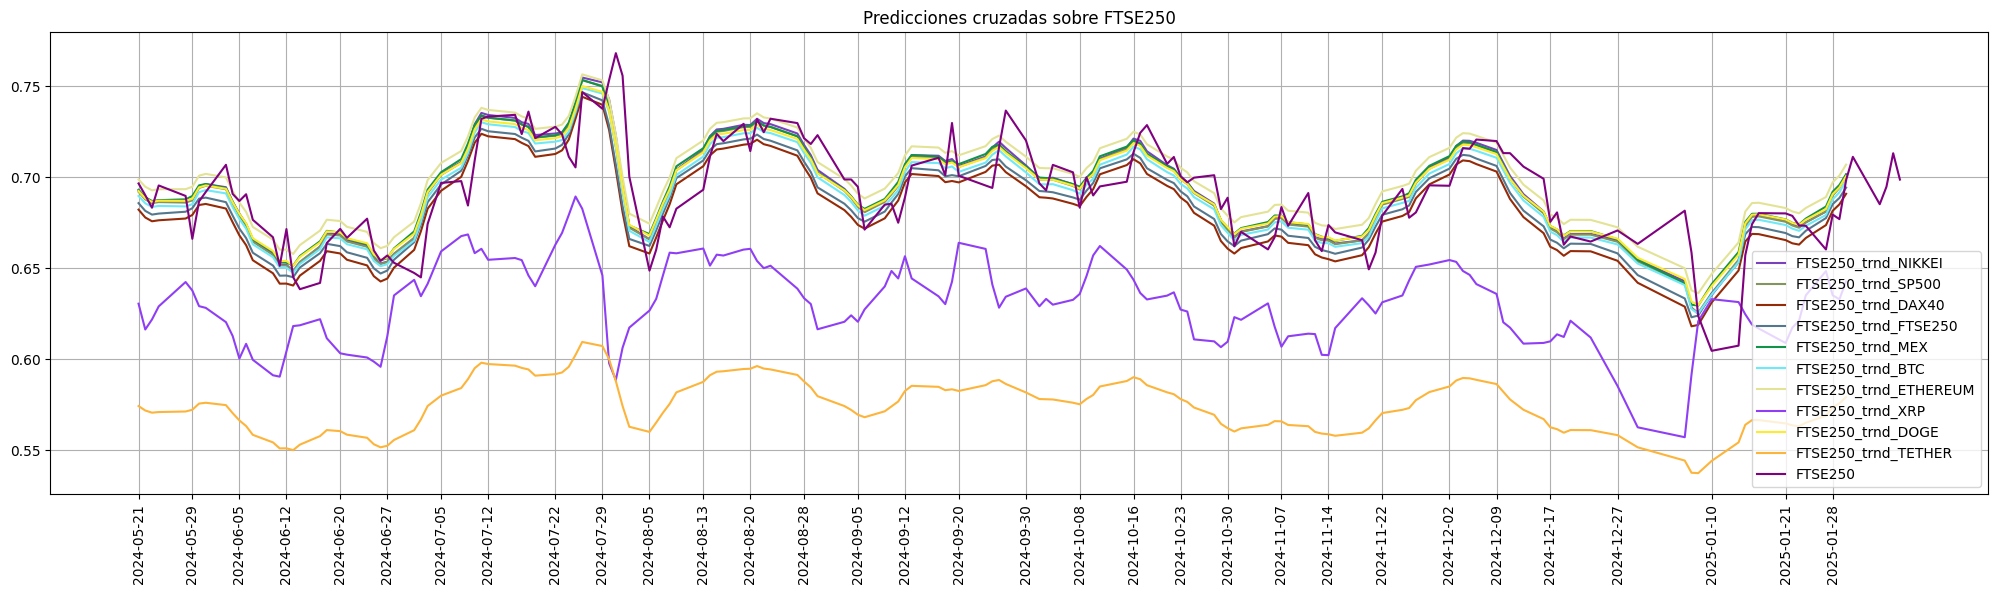

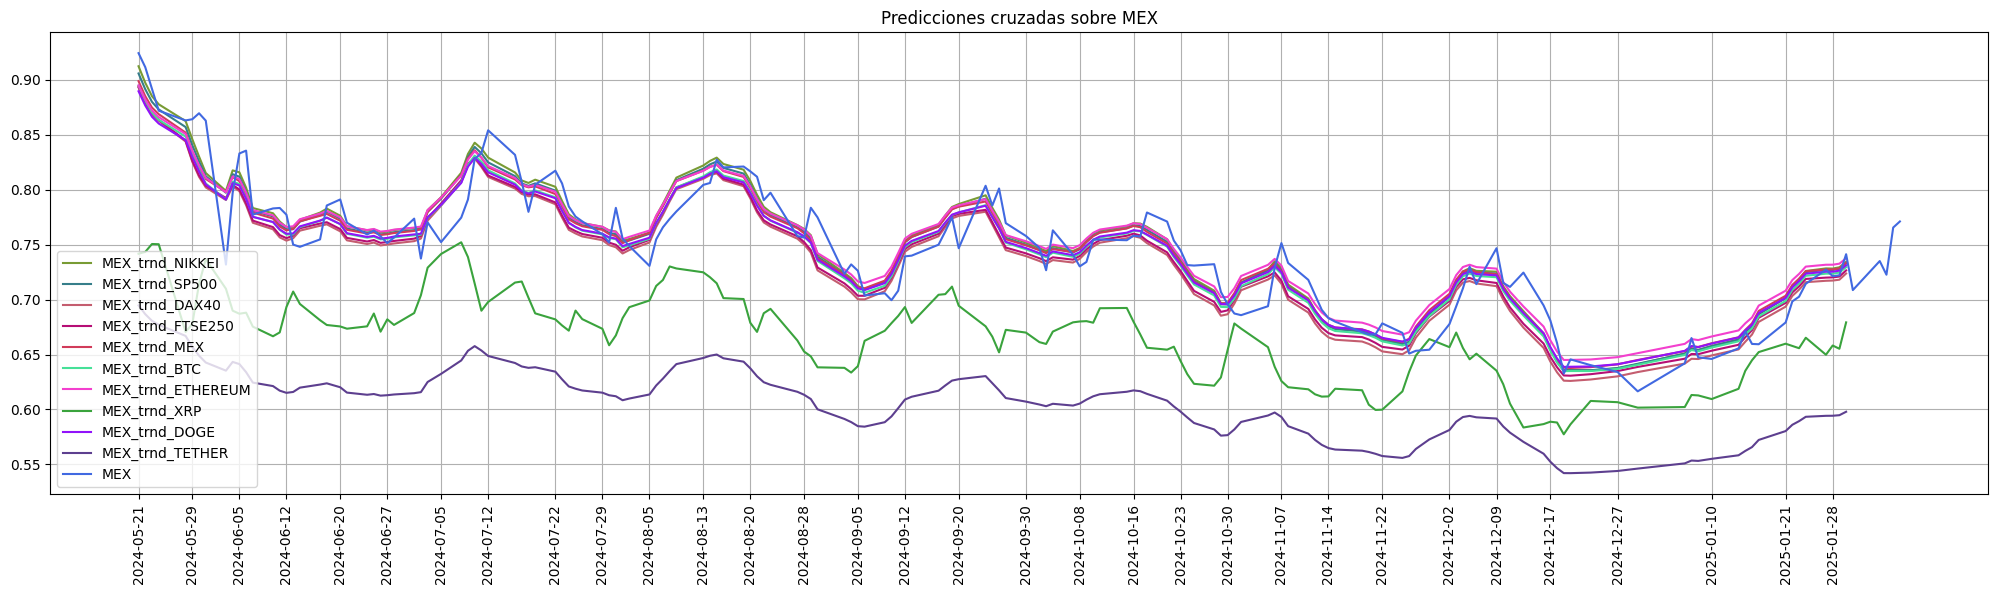

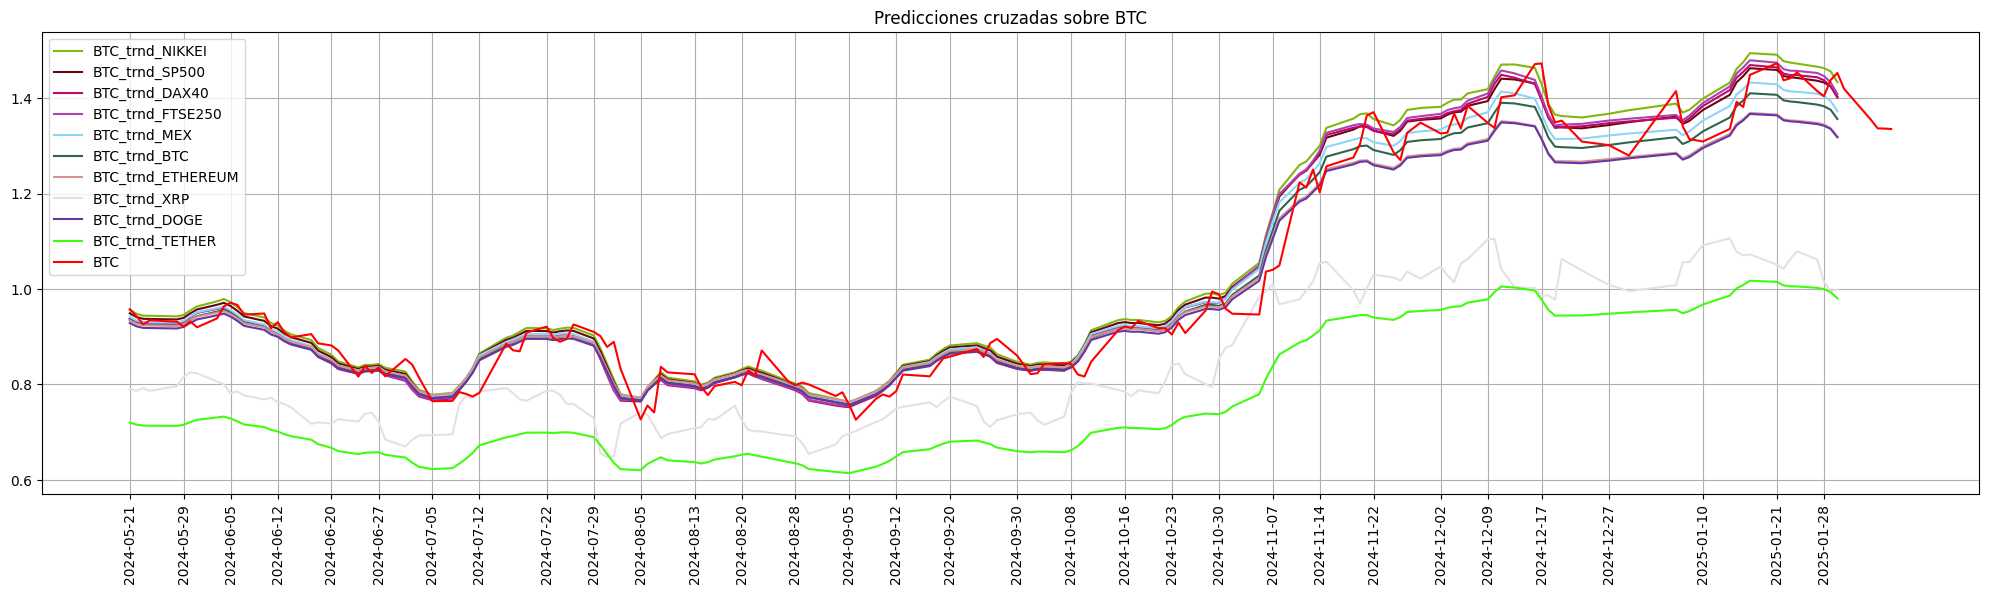

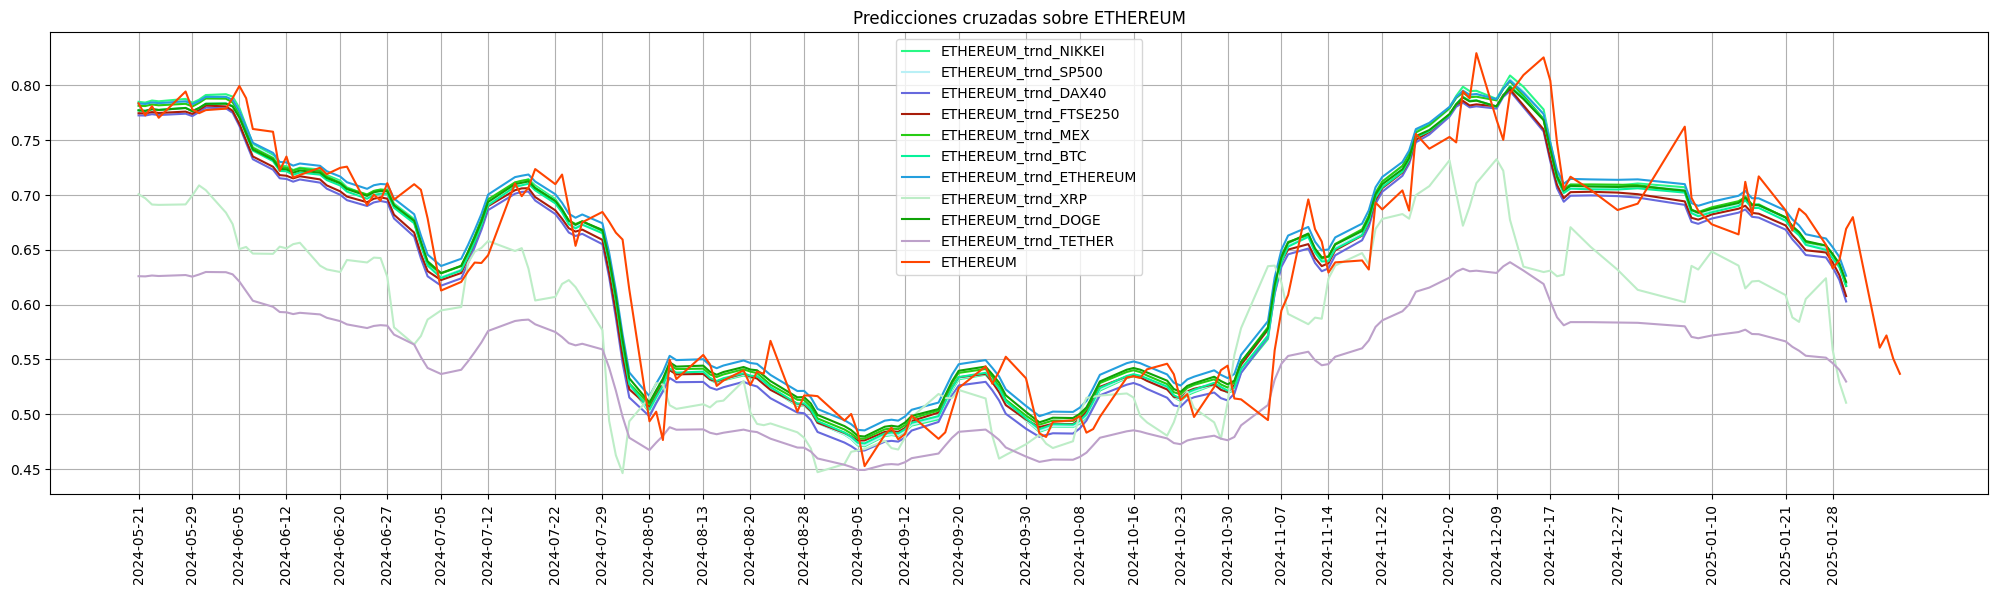

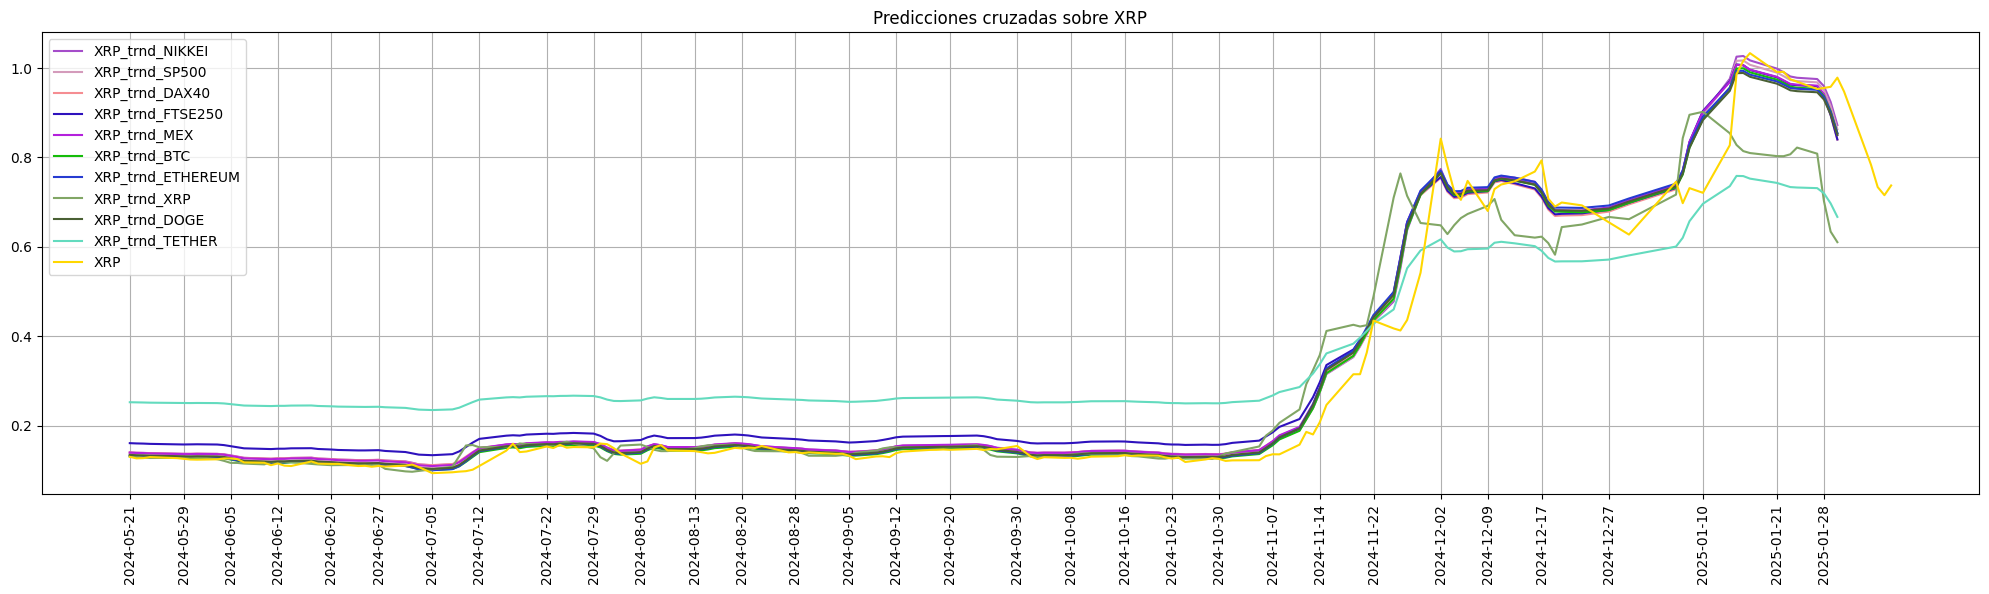

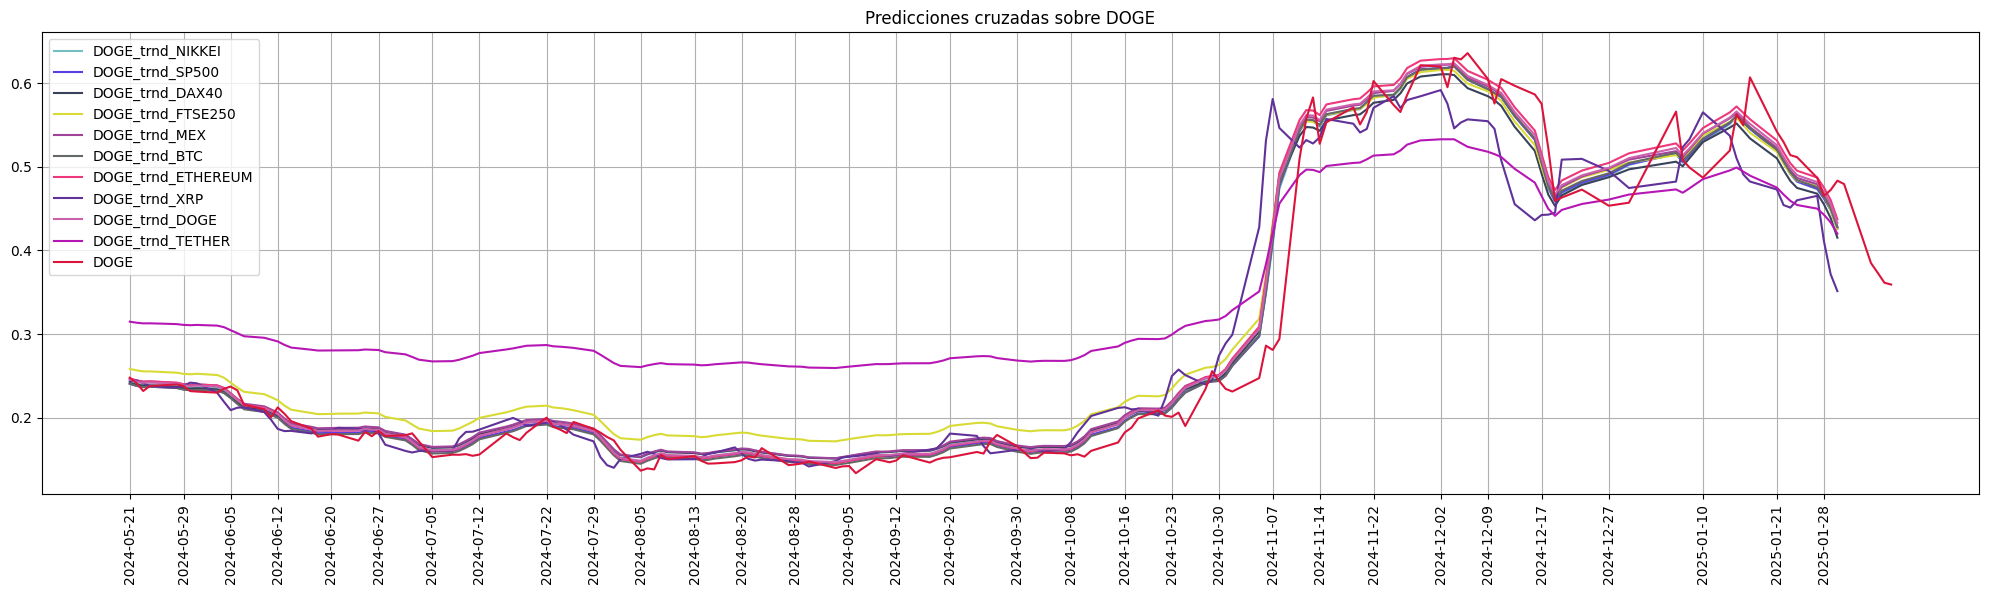

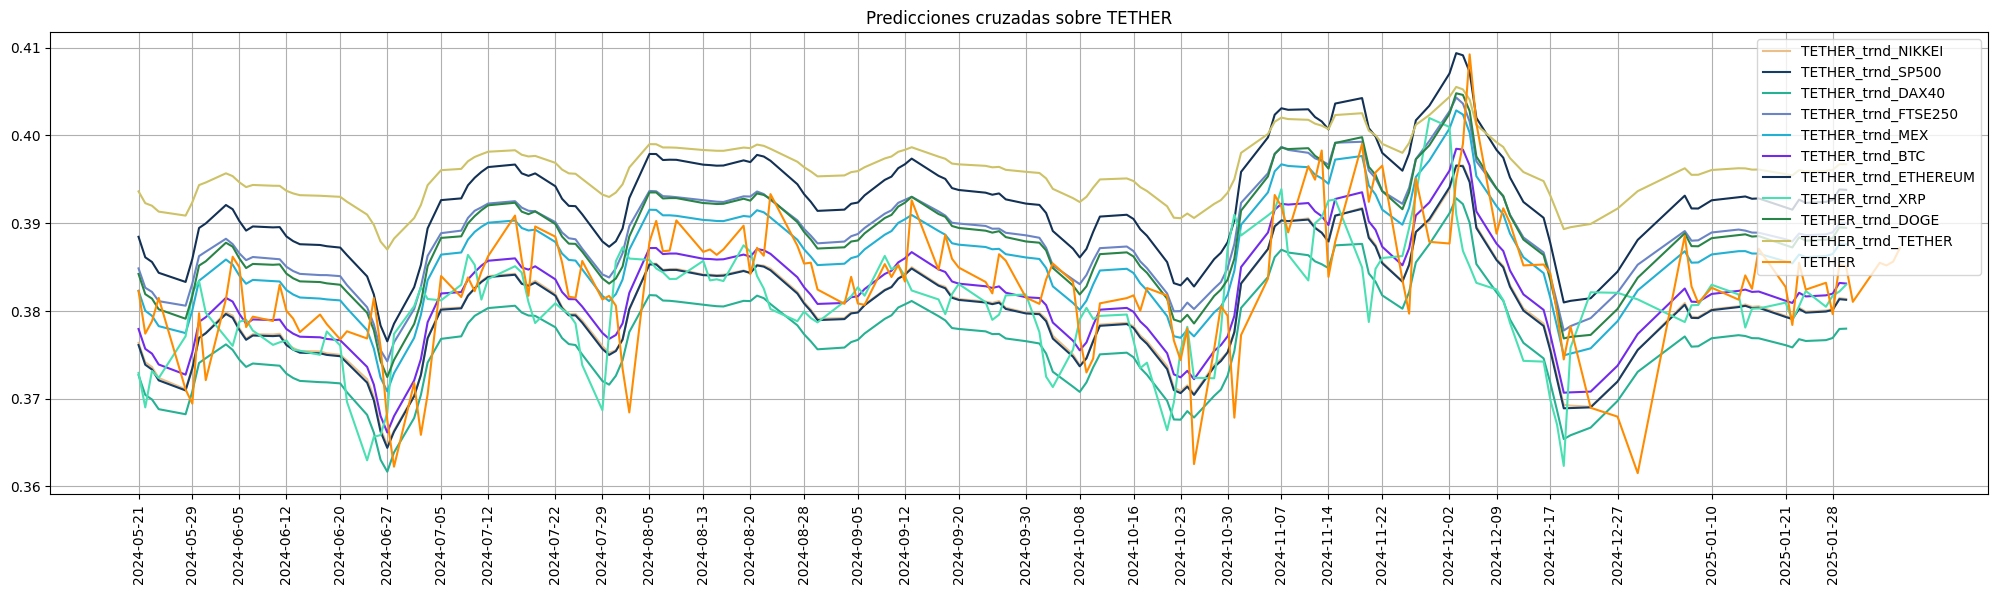

In [ ]:
#Comparamos todas las predicciones:
for i in range(10):
  tf.plot_the_TimeSeries(cross_pred[i::10]+[test_time_series[i]], title = f"Predicciones cruzadas sobre {tf.nombres[i]}",
                         xticks = tf.ref_time_series.data.index[um.len_train:-5:5]
                         )

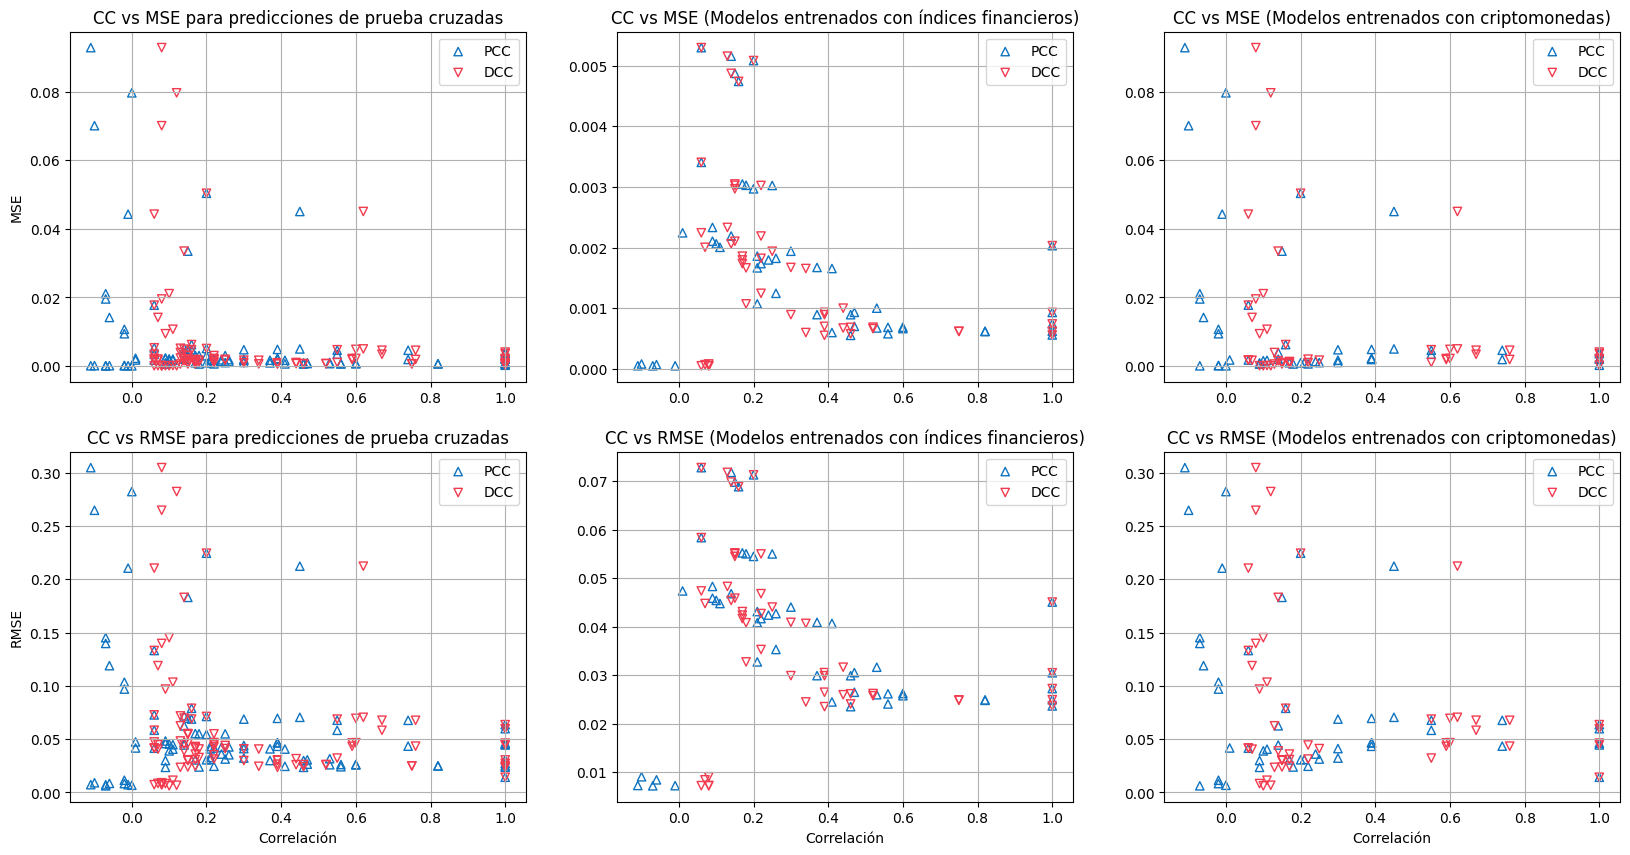

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes[0,0].set_title("CC vs MSE para predicciones de prueba cruzadas")
axes[0,0].scatter(pccs, mses, marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,0].scatter(dccs, mses, marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,0].set_ylabel("MSE")
axes[0,0].legend(["PCC", "DCC"])
axes[0,0].grid()

#TRND WITH FININDEX
axes[0,1].set_title("CC vs MSE (Modelos entrenados con índices financieros)")
axes[0,1].scatter(pccs[:50], mses[:50], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,1].scatter(dccs[:50], mses[:50], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,1].legend(["PCC", "DCC"])
axes[0,1].grid()

#TRND WITH CRIPTOS
axes[0,2].set_title("CC vs MSE (Modelos entrenados con criptomonedas)")
axes[0,2].scatter(pccs[50:], mses[50:], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,2].scatter(dccs[50:], mses[50:], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,2].legend(["PCC", "DCC"])
axes[0,2].grid()


axes[1,0].set_title("CC vs RMSE para predicciones de prueba cruzadas")
axes[1,0].scatter(pccs, rmses, marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,0].scatter(dccs, rmses, marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,0].set_xlabel("Correlación")
axes[1,0].set_ylabel("RMSE")
axes[1,0].legend(["PCC", "DCC"])
axes[1,0].grid()

#TRND WITH FININDEX
axes[1,1].set_title("CC vs RMSE (Modelos entrenados con índices financieros)")
axes[1,1].scatter(pccs[:50], rmses[:50], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,1].scatter(dccs[:50], rmses[:50], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,1].set_xlabel("Correlación")
axes[1,1].legend(["PCC", "DCC"])
axes[1,1].grid()

#TRND WITH CRIPTOS
axes[1,2].set_title("CC vs RMSE (Modelos entrenados con criptomonedas)")
axes[1,2].scatter(pccs[50:], rmses[50:], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,2].scatter(dccs[50:], rmses[50:], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,2].set_xlabel("Correlación")
axes[1,2].legend(["PCC", "DCC"])
axes[1,2].grid()

In [ ]:
indices = [get_the_scatter_index(["NIKKEI", "BTC"])[0], get_the_scatter_index(["NIKKEI", "XRP"])[0],
           get_the_scatter_index(["NIKKEI", "DOGE"])[0], get_the_scatter_index(["NIKKEI", "TETHER"])[0],
           get_the_scatter_index(["SP500", "TETHER"])[0], get_the_scatter_index(["DAX40", "FTSE250"])[0],
           get_the_scatter_index(["FTSE250", "DAX40"])[0], get_the_scatter_index(["ETHEREUM", "BTC"])[0],
           get_the_scatter_index(["BTC", "ETHEREUM"])[0], get_the_scatter_index(["TETHER", "SP500"])[0],
           get_the_scatter_index(["BTC","NIKKEI"])[0], get_the_scatter_index([ "XRP", "NIKKEI"])[0],
           get_the_scatter_index(["DOGE", "NIKKEI"])[0], get_the_scatter_index(["TETHER", "NIKKEI"])[0]
           ]
pccs_maxmins = pccs[indices]
dccs_maxmins = dccs[indices]
mses_maxmins = mses[indices]
rmses_maxmins = rmses[indices]

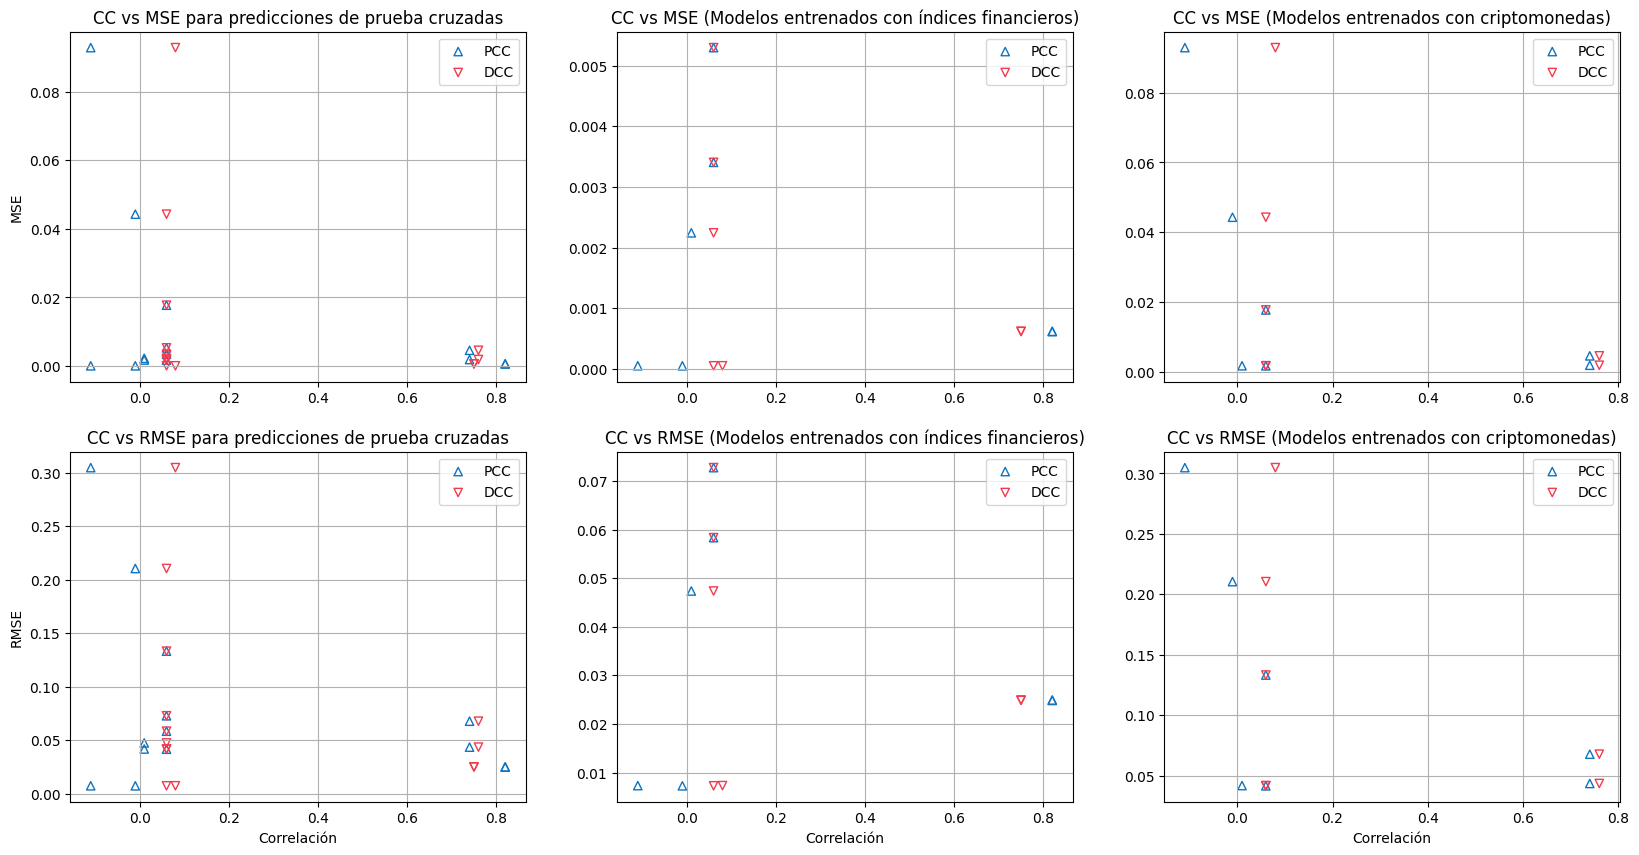

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
#All
axes[0,0].set_title("CC vs MSE para predicciones de prueba cruzadas")
axes[0,0].scatter(pccs_maxmins, mses_maxmins, marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,0].scatter(dccs_maxmins, mses_maxmins, marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,0].set_ylabel("MSE")
axes[0,0].legend(["PCC", "DCC"])
axes[0,0].grid()

#TRND WITH FININDEX
axes[0,1].set_title("CC vs MSE (Modelos entrenados con índices financieros)")
axes[0,1].scatter(pccs_maxmins[:7], mses_maxmins[:7], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,1].scatter(dccs_maxmins[:7], mses_maxmins[:7], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,1].legend(["PCC", "DCC"])
axes[0,1].grid()

#TRND WITH CRIPTOS
axes[0,2].set_title("CC vs MSE (Modelos entrenados con criptomonedas)")
axes[0,2].scatter(pccs_maxmins[7:], mses_maxmins[7:], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[0,2].scatter(dccs_maxmins[7:], mses_maxmins[7:], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[0,2].legend(["PCC", "DCC"])
axes[0,2].grid()

#All
axes[1,0].set_title("CC vs RMSE para predicciones de prueba cruzadas")
axes[1,0].scatter(pccs_maxmins, rmses_maxmins, marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,0].scatter(dccs_maxmins, rmses_maxmins, marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,0].set_xlabel("Correlación")
axes[1,0].set_ylabel("RMSE")
axes[1,0].legend(["PCC", "DCC"])
axes[1,0].grid()

#TRND WITH FININDEX
axes[1,1].set_title("CC vs RMSE (Modelos entrenados con índices financieros)")
axes[1,1].scatter(pccs_maxmins[:7], rmses_maxmins[:7], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,1].scatter(dccs_maxmins[:7], rmses_maxmins[:7], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,1].set_xlabel("Correlación")
axes[1,1].legend(["PCC", "DCC"])
axes[1,1].grid()

#TRND WITH CRIPTOS
axes[1,2].set_title("CC vs RMSE (Modelos entrenados con criptomonedas)")
axes[1,2].scatter(pccs_maxmins[7:], rmses_maxmins[7:], marker = "^", facecolor = "none", edgecolor = "#0e73c0")
axes[1,2].scatter(dccs_maxmins[7:], rmses_maxmins[7:], marker = "v", facecolor = "none", edgecolor = "#f23b4f")
axes[1,2].set_xlabel("Correlación")
axes[1,2].legend(["PCC", "DCC"])
axes[1,2].grid()